Imported Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Regression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

Uploading Dataset

In [3]:
import zipfile
import pandas as pd
from google.colab import files

# Upload zip file
uploaded = files.upload()

# Get uploaded file name automatically
zip_path = list(uploaded.keys())[0]

# Read directly from zip
with zipfile.ZipFile(zip_path) as z:
    with z.open("winequality-red.csv") as f:
        red = pd.read_csv(f, sep=';')

    with z.open("winequality-white.csv") as f:
        white = pd.read_csv(f, sep=';')

# Add type column
red["type"] = "red"
white["type"] = "white"

# Combine datasets
df = pd.concat([red, white], ignore_index=True)

# Preview
df.head()

Saving wine+quality.zip to wine+quality.zip


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


Classification Target

In [4]:
df["good_wine"] = df["quality"].apply(lambda x: 1 if x >= 7 else 0)

Train-Test split

In [9]:
X = df.drop(["quality", "good_wine", "type"], axis=1)

y_class = df["good_wine"]
y_reg = df["quality"]

X_train, X_test, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

_, _, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

Scaling

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Classification Models

In [11]:
class_models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC()
}

In [12]:
class_scores = []

for name, model in class_models.items():
    model.fit(X_train, y_train_class)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test_class, y_pred)
    class_scores.append(acc)
    print(f"{name}: {acc:.3f}")

Logistic: 0.825
Decision Tree: 0.842
Random Forest: 0.887
Naive Bayes: 0.761
SVM: 0.837


Confusion Matrix

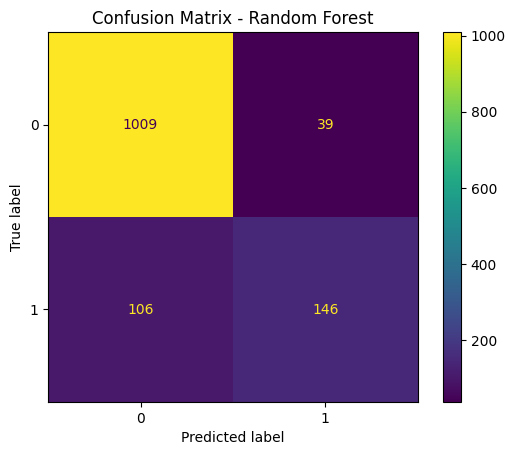

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use best model (example: Random Forest)
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train_class)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test_class, y_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

Feature Importance

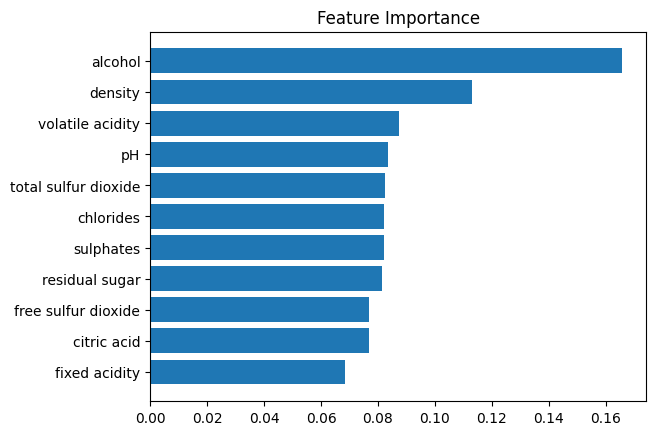

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming Random Forest is best model
importances = best_model.feature_importances_

feature_names = X.columns

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

Comparison

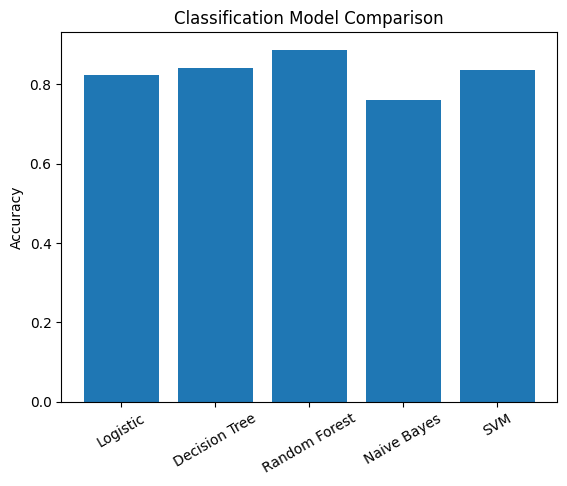

In [13]:
plt.bar(class_models.keys(), class_scores)
plt.title("Classification Model Comparison")
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.show()

Regression Models

In [14]:
reg_models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

In [15]:
reg_scores = []

for name, model in reg_models.items():
    model.fit(X_train, y_train_reg)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test_reg, y_pred)
    reg_scores.append(r2)

    print(f"{name}: R2 = {r2:.3f}")

Linear: R2 = 0.260
Ridge: R2 = 0.260
KNN: R2 = 0.333
Decision Tree: R2 = 0.068
Random Forest: R2 = 0.496


Comparison

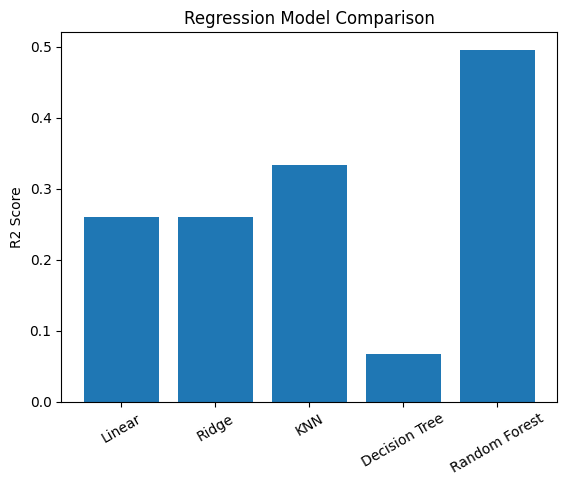

In [16]:
plt.bar(reg_models.keys(), reg_scores)
plt.title("Regression Model Comparison")
plt.xticks(rotation=30)
plt.ylabel("R2 Score")
plt.show()